# Proyecto: K Nearest Neighbors

## Importar librerías

In [ ]:
# Librerías estándar
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocesamiento y modelado
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

## Cargar dataset

In [2]:
# Instancear el url 
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
# Leer el csv y asignar a df
df = pd.read_csv(url, sep=";")	

In [3]:
# Guardar el csv en la carpeta raw
df.to_csv("/workspaces/efrainnalmeida-k-nearest-neighbors-project-tutorial/data/raw/winequality-red.csv", index=False)

# Guardar el csv en la carpeta interim
df.to_csv("/workspaces/efrainnalmeida-k-nearest-neighbors-project-tutorial/data/interim/winequality-red.csv", index=False)

In [4]:
# Leer el csv de la carpeta interim y asignar a df_interim
df_interim = pd.read_csv("/workspaces/efrainnalmeida-k-nearest-neighbors-project-tutorial/data/interim/winequality-red.csv", sep=",")

## EDA

In [5]:
# Mostrar la forma de df_interim
df_interim.shape

(1599, 12)

In [6]:
# Mostrar información general de df_interim
df_interim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
# Mostrar las primeras filas de df_interim
df_interim.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
# Mostrar estadísticas generales de df_interim
df_interim.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [9]:
# Ver frecuencia absoluta y relativa de la variable 'quality'
print(df_interim['quality'].value_counts())
print(df_interim['quality'].value_counts(normalize=True))

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64
quality
5    0.425891
6    0.398999
7    0.124453
4    0.033146
8    0.011257
3    0.006254
Name: proportion, dtype: float64


In [10]:
# Convertir la variable 'quality' en clasificación multiclase

# Definir función para categorizar calidad
def categorizar_calidad(q):
    if q <= 4:
        return 0  # Baja calidad
    elif q <= 6:
        return 1  # Calidad media
    else:
        return 2  # Alta calidad

df_interim['label'] = df_interim['quality'].apply(categorizar_calidad)

# Verificar distribución de la nueva etiqueta
print(df_interim['label'].value_counts())
print(df_interim['label'].value_counts(normalize=True))


label
1    1319
2     217
0      63
Name: count, dtype: int64
label
1    0.824891
2    0.135710
0    0.039400
Name: proportion, dtype: float64


In [11]:
# Separar features y target
X = df_interim.drop(columns=['quality', 'label'])
y = df_interim['label']

In [12]:
# Escalado de variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# Dividir entre train y test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# Convertir X_train y X_test nuevamente a DataFrame con los mismos nombres de columnas que X
X_columns = X.columns if isinstance(X, pd.DataFrame) else [f"feature_{i}" for i in range(X.shape[1])]
X_train_df = pd.DataFrame(X_train, columns=X_columns)
X_test_df = pd.DataFrame(X_test, columns=X_columns)

# Agregar la columna 'label'
train_df = X_train_df.copy()
train_df['label'] = y_train.reset_index(drop=True)

test_df = X_test_df.copy()
test_df['label'] = y_test.reset_index(drop=True)

# Guardar como CSV en carpeta processed
train_df.to_csv("/workspaces/efrainnalmeida-k-nearest-neighbors-project-tutorial/data/processed/clean_train.csv", index=False)
test_df.to_csv("/workspaces/efrainnalmeida-k-nearest-neighbors-project-tutorial/data/processed/clean_test.csv", index=False)

## Modelo KNN

In [15]:
# Entrenar el modelo
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [16]:
# Predecir
y_pred = knn.predict(X_test)

In [17]:
# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

# 2. Matriz de confusión
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

# 3. Reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["Baja", "Media", "Alta"]))

# 4. AUC-ROC multiclase (One-vs-Rest)
# Binarizar etiquetas reales
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Obtener probabilidades de predicción
y_score = knn.predict_proba(X_test)

# Calcular AUC-ROC macro
auc_score = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='macro')
print(f"\nAUC-ROC multiclase (OvR, promedio macro): {auc_score:.3f}")


Accuracy: 0.819

Matriz de Confusión:
[[  0  13   0]
 [  1 243  20]
 [  0  24  19]]

Reporte de Clasificación:
              precision    recall  f1-score   support

        Baja       0.00      0.00      0.00        13
       Media       0.87      0.92      0.89       264
        Alta       0.49      0.44      0.46        43

    accuracy                           0.82       320
   macro avg       0.45      0.45      0.45       320
weighted avg       0.78      0.82      0.80       320


AUC-ROC multiclase (OvR, promedio macro): 0.760


## Optimización

k=1: Accuracy=0.8187
k=2: Accuracy=0.8156
k=3: Accuracy=0.8250
k=4: Accuracy=0.8250
k=5: Accuracy=0.8187
k=6: Accuracy=0.8438
k=7: Accuracy=0.8438
k=8: Accuracy=0.8344
k=9: Accuracy=0.8406
k=10: Accuracy=0.8500
k=11: Accuracy=0.8531
k=12: Accuracy=0.8594
k=13: Accuracy=0.8438
k=14: Accuracy=0.8344
k=15: Accuracy=0.8344
k=16: Accuracy=0.8375
k=17: Accuracy=0.8281
k=18: Accuracy=0.8375
k=19: Accuracy=0.8344
k=20: Accuracy=0.8375


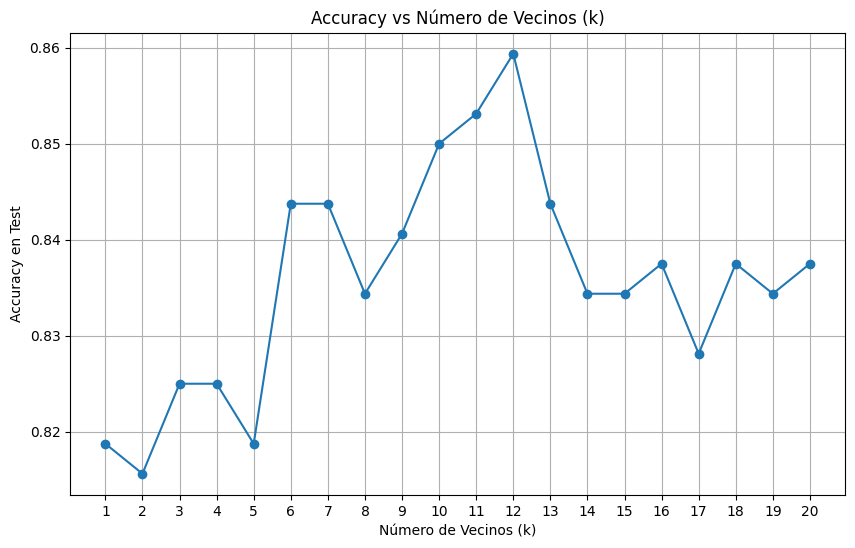

In [26]:
# Lista para guardar los resultados
accuracy_scores = []

# Probar k de 1 a 20
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred_k)
    accuracy_scores.append(acc)

# Mostrar los resultados
for i, acc in enumerate(accuracy_scores, 1):
    print(f"k={i}: Accuracy={acc:.4f}")

# Graficar con matplotlib
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), accuracy_scores, marker='o')
plt.title("Accuracy vs Número de Vecinos (k)")
plt.xlabel("Número de Vecinos (k)")
plt.ylabel("Accuracy en Test")
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

In [29]:
# 1. Encontrar el mejor k automáticamente
best_k = np.argmax(accuracy_scores) + 1
print(f"Mejor valor de k encontrado: {best_k}")

# 2. Entrenar el modelo con el mejor k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

# 3. Accuracy
accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy (k={best_k}): {accuracy:.3f}")

# 4. Matriz de confusión
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_best))

# 5. Reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_best, target_names=["Baja", "Media", "Alta"], zero_division=0))

# 6. AUC-ROC multiclase (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score_best = knn_best.predict_proba(X_test)

auc_score_best = roc_auc_score(y_test_bin, y_score_best, multi_class='ovr', average='macro')
print(f"\nAUC-ROC multiclase (OvR, promedio macro): {auc_score_best:.3f}")

Mejor valor de k encontrado: 12

Accuracy (k=12): 0.859

Matriz de Confusión:
[[  0  13   0]
 [  0 253  11]
 [  0  21  22]]

Reporte de Clasificación:
              precision    recall  f1-score   support

        Baja       0.00      0.00      0.00        13
       Media       0.88      0.96      0.92       264
        Alta       0.67      0.51      0.58        43

    accuracy                           0.86       320
   macro avg       0.52      0.49      0.50       320
weighted avg       0.82      0.86      0.84       320


AUC-ROC multiclase (OvR, promedio macro): 0.786


## Guardar modelo

In [33]:
# Ruta
ruta_modelo = "/workspaces/efrainnalmeida-k-nearest-neighbors-project-tutorial/models/knn_model_k12.pkl"

# Guardar modelo entrenado
with open(ruta_modelo, 'wb') as file:
    pickle.dump(knn_best, file)

print(f"Modelo guardado exitosamente en:\n{ruta_modelo}")

Modelo guardado exitosamente en:
/workspaces/efrainnalmeida-k-nearest-neighbors-project-tutorial/models/knn_model_k12.pkl


## Función final para predecir calidad del vino

In [36]:
# Definir función para cargar el modelo
def predict_wine_quality(features):
    """
    Recibe una lista de 11 características químicas de un vino
    y devuelve una predicción de calidad: baja, media o alta.
    """
    # Crear un DataFrame con los mismos nombres de columnas usados en el entrenamiento
    feature_names = X.columns  # Usa las columnas originales
    features_df = pd.DataFrame([features], columns=feature_names)

    # Escalar
    features_scaled = scaler.transform(features_df)

    # Predecir
    pred = knn_best.predict(features_scaled)[0]

    if pred == 0:
        return "Este vino probablemente sea de baja calidad 🍷"
    elif pred == 1:
        return "Este vino probablemente sea de calidad media 🍷"
    else:
        return "Este vino probablemente sea de alta calidad 🍷"

In [37]:
# Prueba de la función
ejemplo = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]

resultado = predict_wine_quality(ejemplo)
print("\nPredicción de ejemplo:", resultado)


Predicción de ejemplo: Este vino probablemente sea de calidad media 🍷
